# Analyze fitness effects

Import Python modules

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import glob
from collections import defaultdict
import math
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')
import scipy
from Bio import SeqIO
from Bio.Seq import Seq

Read in data

In [2]:
# Read in fitness effects of amino-acid mutations
fitness_df = pd.read_csv('../results/aa_fitness_effects.csv', keep_default_na=False)
fitness_df = fitness_df[fitness_df['host'] == 'all']

# Read in data on fitness effects of synonymous mutations at a given site
site_syn_fitness_df = pd.read_csv('../results/sitewise_synonymous_fitness_effects.csv', keep_default_na=False)
site_syn_fitness_df = site_syn_fitness_df[site_syn_fitness_df['host'] == 'all']

Plot the distribution of effects

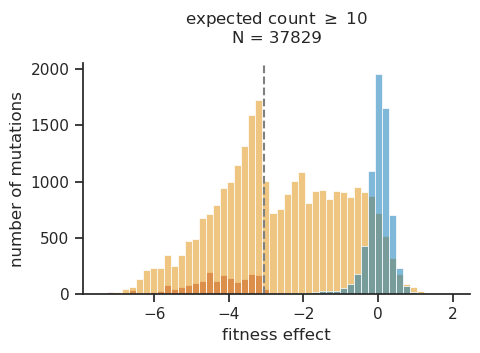

In [3]:
mut_class_colors = {
    'synonymous' : '#0173b2',
    'nonsynonymous' : '#de8f05',
    'nonsense' : 'firebrick',
}

count_threshold = 10
data = fitness_df[fitness_df['expected_count'] >= count_threshold].copy()
fitness_lod = np.log(0.5/(count_threshold+0.5))
data['delta_fitness'] = data['delta_fitness'].clip(upper=2.0)
plt.figure(figsize=(5,3))
ax = sns.histplot(
    x='delta_fitness', data=data, bins=50,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors, legend=False
)
plt.axvline(fitness_lod, color='gray', linestyle='--')
plt.xlabel('fitness effect')
plt.ylabel('number of mutations')
plt.title(f'expected count $\geq$ {count_threshold}\nN = {len(data)}', y=1.05)
sns.despine()
plt.show()

Plot distributions of fitness effects as a function of gene.

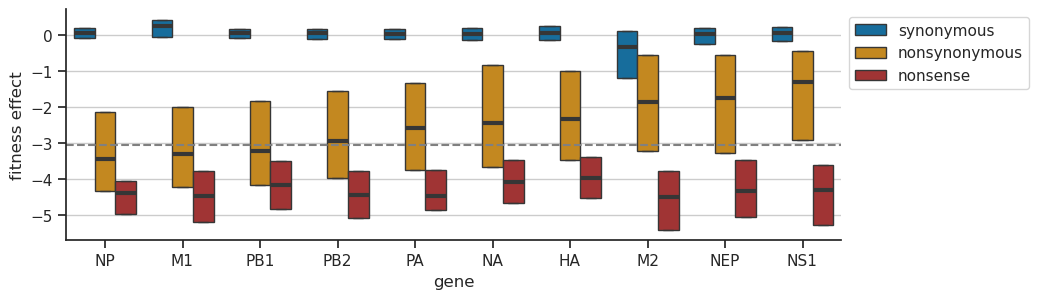

In [4]:
# Get data
count_threshold = 10
data = fitness_df[fitness_df['expected_count'] >= count_threshold].copy()
fitness_lod = np.log(0.5/(count_threshold+0.5))

# TODO: remove
data['gene'] = data['gene'].apply(lambda x: x.upper())
data = data[data['gene'] != 'PB1;PB1-F2']

# Explode dataframe so that there is one row per mutation per gene
data['gene'] = data['gene'].str.split(';')
data['codon_site'] = data['codon_site'].str.split(';')
data = data.explode(['gene', 'codon_site'])

# Sort dataframe by median delta_fitness of nonsynonymous mutations
nonsynonymous_medians = (
    data[data['mut_class'] == 'nonsynonymous']
    .groupby('gene', as_index=False)['delta_fitness']
    .median()
    .sort_values('delta_fitness')
    .rename(columns={'delta_fitness':'median_nonsyn_fitness'})
)
data = (
    data
    .merge(nonsynonymous_medians)
    .sort_values('median_nonsyn_fitness', ascending=True)
)

# Plot data
plt.figure(figsize=[10,3])
sns.boxplot(
    x='gene', y='delta_fitness', data=data,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors,
    medianprops={"linewidth": 3}, showfliers=False, whis=(50,50)
)
plt.axhline(fitness_lod, color='gray', linestyle='--')
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel('fitness effect')
sns.despine()
plt.show()

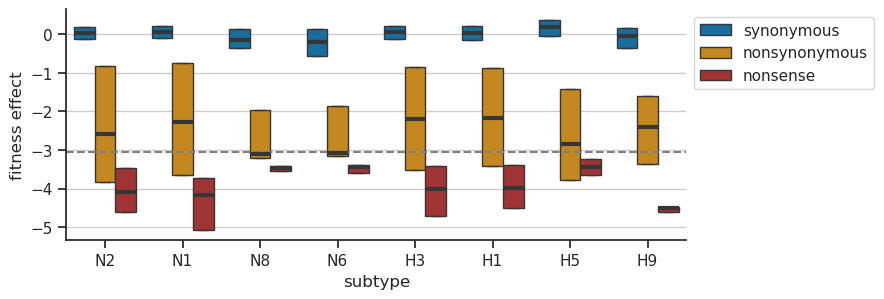

In [5]:
# Get data for HA/NA subtypes with at least 100 mutations with estimated fitness effects
ha_na_data = data[data['gene'].isin(['HA', 'NA'])].copy()
subtype_counts = ha_na_data['subtype'].value_counts()
subtypes_to_include = subtype_counts[subtype_counts >= 100].index
ha_na_data = ha_na_data[ha_na_data['subtype'].isin(subtypes_to_include)]

# Plot distributions for different HA and NA subtypes
plt.figure(figsize=[8,3])
sns.boxplot(
    x='subtype', y='delta_fitness', data=ha_na_data,
    hue='mut_class', hue_order=['synonymous', 'nonsynonymous', 'nonsense'],
    palette=mut_class_colors,
    medianprops={"linewidth": 3}, showfliers=False, whis=(50,50)
)
plt.axhline(fitness_lod, color='gray', linestyle='--')
plt.grid(axis='y')
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel('fitness effect')
sns.despine()
plt.show()

Examine the fitness effects of synonymous mutation across the genome.

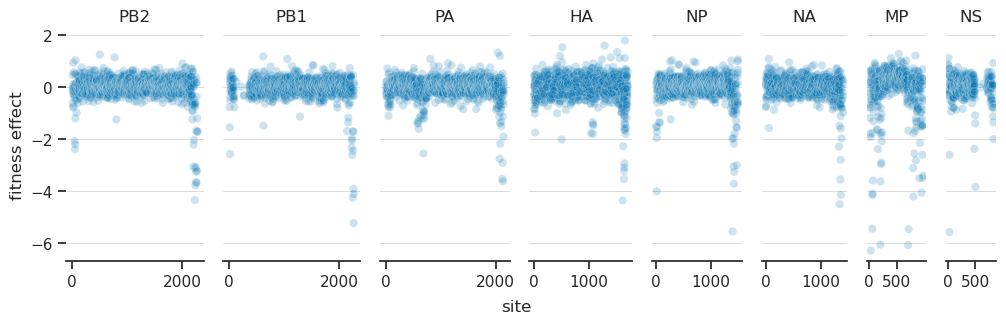

In [6]:
# Get data
count_threshold = 25
mut_classes_to_plot = ['synonymous']
syn_data = site_syn_fitness_df[
    # (site_syn_fitness_df['subtype'].isin(['all', 'H3', 'N2'])) &
    (site_syn_fitness_df['mut_class'].isin(mut_classes_to_plot)) &
    (site_syn_fitness_df['expected_count'] >= count_threshold)
].copy()

# Get width ratios for plotting segments
segments = ['PB2', 'PB1', 'PA', 'HA', 'NP', 'NA', 'MP', 'NS']
width_ratios = []
for segment in segments:
    # TODO: update with more accurate width ratios
    data = site_syn_fitness_df[site_syn_fitness_df['segment'] == segment]
    width_ratios.append(data['site'].max())

# Plot data
(fig, axs) = plt.subplots(
    ncols=len(segments), sharey=True, figsize=[12, 3],
    gridspec_kw={'width_ratios': width_ratios}
)
for (i, segment) in enumerate(segments):
    data = syn_data[(syn_data['segment'] == segment)]
    sns.scatterplot(
        x='site', y='delta_fitness', data=data, ax=axs[i], alpha=0.2,
        hue='mut_class', palette=mut_class_colors
    )
    axs[i].grid(axis='y', which='both', lw=0.5)
    axs[i].set(title=segment, xlabel='')
    axs[i].get_legend().remove()
    if i > 0:
        axs[i].tick_params(axis='y', which='both', left=False, labelleft=False)
    if segment in ['MP', 'NS']:
        axs[i].set(xticks=[0, 500])
    sns.despine(left=True, ax=axs[i])

axs[0].set(ylabel='fitness effect')
fig.text(0.5, -0.06, 'site', ha='center')
plt.show()

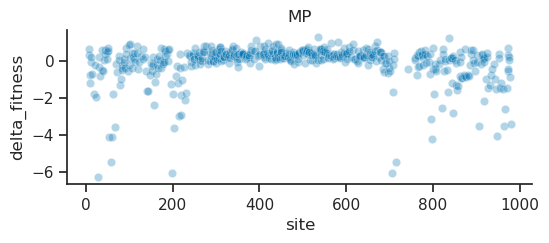

In [7]:
segment = 'MP'
data = syn_data[(syn_data['segment'] == segment)]
plt.figure(figsize=[6,2])
sns.scatterplot(x='site', y='delta_fitness', data=data, alpha=0.3)
plt.title(segment)
sns.despine()
plt.show()

## Compare estimated fitness effects to experimentally measured DMS data

Compare fitness effects to DMS data for HA.

In [8]:
# Get fitness data
count_threshold_dms_comparison = 25
fitness_lod_dms_comparison = np.log(0.5/(count_threshold_dms_comparison+0.5))
ha_fitness_data = fitness_df[
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['gene'] == 'HA') &
    (fitness_df['subtype'] == 'H3')
].copy()
ha_fitness_data['codon_site'] = ha_fitness_data['codon_site'].astype(int)

# Read in processed DMS data and merge with fitness data
ha_dms_data = pd.read_csv('../results/dms_data/Yu_HA/processed_dms_data.csv')
ha_dms_data = (
    ha_dms_data
    .rename(columns={'tree_reference_site' : 'codon_site'})
    .merge(ha_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(ha_dms_data))
print('N sites with data:', ha_dms_data['codon_site'].nunique())
ha_dms_data.head()

N muts with data: 1299
N sites with data: 503


,site,wt_aa,mut_aa,sera_escape,dms_effect,pH_stability,sequential_site,n_nt_changes,codon_site,reference_site,sequential_wt,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
0,1,Q,K,0.04918,-0.1115,0.001008,1,1,17,1,Q,all,H3,HA,HA,Q17K,nonsynonymous,53,41.625490,0.239029
1,1,Q,R,-0.19230,-0.8861,0.012610,1,1,17,1,Q,all,H3,HA,HA,Q17R,nonsynonymous,18,45.669259,-0.914543
2,2,K,E,-0.06889,-0.3198,0.050210,2,1,18,2,K,all,H3,HA,HA,K18E,nonsynonymous,75,78.135229,-0.040687
3,2,K,R,-0.10240,-0.6128,0.060580,2,1,18,2,K,all,H3,HA,HA,K18R,nonsynonymous,63,78.280932,-0.215631
6,3,I,V,-0.05354,-0.4621,0.012070,3,1,19,3,I,all,H3,HA,HA,I19V,nonsynonymous,52,70.368641,-0.300015


0.8202680377095565


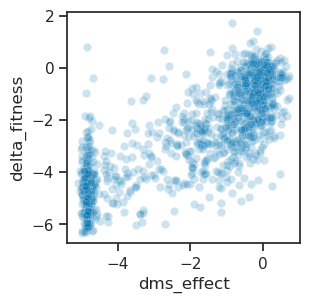

In [9]:
print(ha_dms_data['dms_effect'].corr(ha_dms_data['delta_fitness']))
plt.figure(figsize=[3,3])
sns.scatterplot(x='dms_effect', y='delta_fitness', data=ha_dms_data, alpha=0.2)
plt.show()

Compare fitness effects to DMS data for NP.

In [10]:
# Get fitness data
np_fitness_data = fitness_df[
    (fitness_df['gene'] == 'NP') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold_dms_comparison) &
    (fitness_df['subtype'] == 'all')
].copy()
np_fitness_data['codon_site'] = np_fitness_data['codon_site'].astype(int)

# Read in data and merge with fitness data. The sites are indexed in the exact same way.
np_dms_data = (
    pd.read_csv('../results/dms_data/Bloom_NP/processed_dms_data.csv')
    .rename(columns={'site':'codon_site'})
    .merge(np_fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(np_dms_data))
print('N sites with data:', np_dms_data['codon_site'].nunique())
np_dms_data

N muts with data: 1851
N sites with data: 485


,codon_site,wt_aa,mut_aa,preference,wt_preference,dms_effect,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
1504,1,M,T,0.032492,0.391903,-2.490014,all,all,NP,NP,M1T,nonsynonymous,0,128.139409,-5.550160
1237,1,M,R,0.028061,0.391903,-2.636616,all,all,NP,NP,M1R,nonsynonymous,0,25.209237,-3.939998
543,1,M,I,0.023434,0.391903,-2.816809,all,all,NP,NP,M1I,nonsynonymous,0,354.776488,-6.566044
697,1,M,K,0.038531,0.391903,-2.319554,all,all,NP,NP,M1K,nonsynonymous,0,39.492699,-4.381844
182,2,A,E,0.015231,0.753436,-3.901298,all,all,NP,NP,A2E,nonsynonymous,4,160.768583,-3.578994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
696,498,N,I,0.073817,0.088315,-0.179316,all,all,NP,NP,N498I,nonsynonymous,17,30.294450,-0.565134
853,498,N,K,0.276824,0.088315,1.142474,all,all,NP,NP,N498K,nonsynonymous,12,40.799923,-1.195132
1850,498,N,Y,0.011276,0.088315,-2.058196,all,all,NP,NP,N498Y,nonsynonymous,5,27.215391,-1.617240
1635,498,N,T,0.063578,0.088315,-0.328635,all,all,NP,NP,N498T,nonsynonymous,3,28.448872,-2.112768


0.45818783143073244


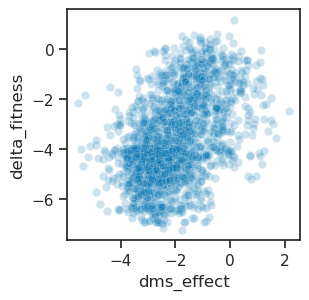

In [11]:
print(np_dms_data['dms_effect'].corr(np_dms_data['delta_fitness']))
plt.figure(figsize=[3,3])
sns.scatterplot(x='dms_effect', y='delta_fitness', data=np_dms_data, alpha=0.2)
plt.show()

Compare fitness effects to DMS data for PB2.

In [12]:
# Get fitness data
count_threshold = 25
fitness_lod = np.log(0.5/(count_threshold+0.5))
fitness_data = fitness_df[
    (fitness_df['gene'] == 'PB2') &
    (fitness_df['mut_class'] == 'nonsynonymous') &
    (fitness_df['expected_count'] >= count_threshold) &
    (fitness_df['subtype'] == 'all')
].copy()
fitness_data['codon_site'] = fitness_data['codon_site'].astype(int)

# Read in the DMS data and merge with the fitness data
pb2_dms_data = (
    pd.read_csv('../data/dms_data/Soh_PB2/elife-45079-fig2-data1-v1.csv')
    .rename(columns={
        'site':'codon_site',
        'wildtype' : 'wt_aa', 
        'mutation' : 'mut_aa',
        'log2effectA549': 'dms_effect'
    })
    .merge(fitness_data, on=['codon_site', 'wt_aa', 'mut_aa'], how='inner')
    .sort_values('codon_site')
)
print('N muts with data:', len(pb2_dms_data))
print('N sites with data:', pb2_dms_data['codon_site'].nunique())
pb2_dms_data.head()

N muts with data: 2617
N sites with data: 757


,codon_site,wt_aa,mut_aa,prefA549,prefCCL141,log2prefA549,log2prefCCL141,effectA549,effectCCL141,dms_effect,...,Experimentally adaptive in,host,subtype,segment,gene,aa_mut,mut_class,actual_count,expected_count,delta_fitness
1024,1,M,K,0.045065,0.042917,-4.471848,-4.542299,0.091968,0.118499,-3.442719,...,NaN,all,all,PB2,PB2,M1K,nonsynonymous,0,30.498361,-4.127081
2211,1,M,T,0.037434,0.052167,-4.739489,-4.260707,0.076396,0.144040,-3.710360,...,NaN,all,all,PB2,PB2,M1T,nonsynonymous,0,113.554573,-5.429824
784,1,M,I,0.051935,0.048641,-4.267144,-4.361682,0.105989,0.134303,-3.238015,...,NaN,all,all,PB2,PB2,M1I,nonsynonymous,0,301.404830,-6.403259
520,2,E,G,0.028171,0.012344,-5.149633,-6.340091,0.152174,0.079186,-2.716206,...,NaN,all,all,PB2,PB2,E2G,nonsynonymous,13,252.851661,-2.932089
1025,2,E,K,0.023902,0.043219,-5.386741,-4.532198,0.129111,0.277256,-2.953314,...,NaN,all,all,PB2,PB2,E2K,nonsynonymous,10,415.625507,-3.679612


0.6159234328453349


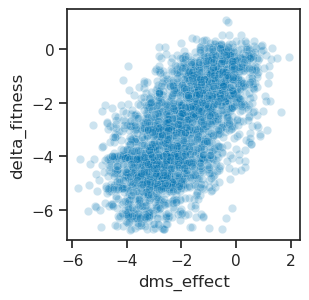

In [13]:
print(pb2_dms_data['dms_effect'].corr(pb2_dms_data['delta_fitness']))
plt.figure(figsize=[3,3])
sns.scatterplot(x='dms_effect', y='delta_fitness', data=pb2_dms_data, alpha=0.2)
plt.show()